In [1]:
from zipfile import ZipFile
file_name='/content/MIt-BIH Datasets.zip'
with ZipFile(file_name,'r') as zip:
  zip.extractall()

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from sklearn.utils import class_weight
import warnings

import keras
from keras.models import Sequential
from keras.models import Model
from keras.layers import Reshape
from keras.layers import Dense, Activation, Flatten, Convolution1D, Dropout,MaxPooling1D
from tensorflow.keras.optimizers import Adam 
from keras.callbacks import LearningRateScheduler

import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error

from tensorflow.keras.layers import BatchNormalization
import cv2
from tensorflow.keras.optimizers import Adam , Adadelta

warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
train = pd.read_csv("/content/MIt-BIH Datasets/train.csv" , header = None)
validate = pd.read_csv("/content/MIt-BIH Datasets/validate.csv", header = None)
test = pd.read_csv("/content/MIt-BIH Datasets/test.csv" , header = None)
display_test = pd.read_csv("/content/test.csv" , header = None)

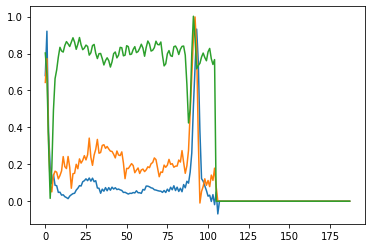

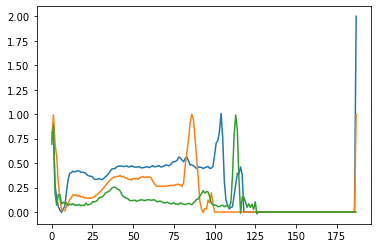

In [4]:
for i in range(3): plt.plot(train.iloc[i])
plt.show()
for i in range(3): plt.plot(test.iloc[i])
plt.show()

In [5]:
train.rename(columns={187:"Class"}, inplace=True)
test.rename(columns={187:"Class"}, inplace=True)
validate.rename(columns={187:"Class"}, inplace=True)
display_test.rename(columns={187:"Class"}, inplace=True)

In [6]:
train['Class'].unique()

array([ 0., 15.,  8., 17.,  2.,  1.,  4., 12.,  5., 14., 10.,  6., 18.])

In [7]:
test['Class'].unique()

array([ 2.,  1.,  0.,  8., 15.,  4., 10.,  5., 12., 17.,  6., 14., 18.])

In [8]:
mapping = {    
               0 : 'Normal Beat',
               1 : 'Left bundle branch block beat',
               2 : 'Right bundle branch block beat',
               4 : 'Atrial premature beat',
               5 : 'Aberrated atrial premature beat',
               6 : 'Nodal (junctional) premature beat',
             
               8 : 'Premature ventricular contraction',
               10 : 'Fusion of ventricular and normal beat',
               
               12 : 'Nodal (junctional) escape beat',
               14 : 'Ventricular escape beat',
               15 : 'Paced beat',
             
               17 : 'Unclassifiable beat',
                18 : 'Fusion of ventricular and normal beat'

               }

In [9]:
train['label'] = train.iloc[:, -1].map(mapping)
test['label'] = test.iloc[:, -1].map(mapping)
validate['label'] = validate.iloc[:, -1].map(mapping)
display_test['label'] = display_test.iloc[:, -1].map(mapping)



In [10]:
# Applying Smote
df_15=train[train['Class']==15]
df_2=train[train['Class']==2]
df_1=train[train['Class']==1]
df_8=train[train['Class']==8]
df_4=train[train['Class']==4]
df_10=train[train['Class']==10]
df_12=train[train['Class']==12]
df_6=train[train['Class']==6]
df_14=train[train['Class']==14]
df_5=train[train['Class']==5]
df_17=train[train['Class']==17]
df_18= train[train['Class']==18]


df_0=(train[train['Class']==0]).sample(n=20000,random_state=42)


train=pd.concat([df_0,df_15,df_2,df_1,df_8,df_4,df_10,df_12,df_6,df_14,df_5,df_17,df_18])

In [11]:
X_train=train.iloc[:,:186].values
X_test=test.iloc[:,:186].values
X_validate = validate.iloc[: , :186].values
X_display = display_test.iloc[: , :186].values

In [12]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=1)
X_train, y_train = oversample.fit_resample(X_train, train["Class"])


In [13]:
from collections import Counter

counter = Counter(y_train)
print(counter)

Counter({0.0: 20000, 15.0: 20000, 2.0: 20000, 1.0: 20000, 8.0: 20000, 4.0: 20000, 10.0: 20000, 12.0: 20000, 6.0: 20000, 14.0: 20000, 5.0: 20000, 17.0: 20000, 18.0: 20000})


In [14]:
X_train = X_train.reshape(len(X_train), X_train.shape[1],1)
X_test = X_test.reshape(len(X_test), X_test.shape[1],1)
X_validate = X_validate.reshape(len(X_validate), X_validate.shape[1],1)
X_display = X_display.reshape(len(X_display), X_display.shape[1],1)

In [15]:
target_test=test["Class"]
target_validate=validate["Class"]
target_display = display_test["Class"]

In [16]:
y_train= np.array(y_train).reshape(-1,1)
y_test= np.array(target_test).reshape(-1,1)
y_validate= np.array(target_validate).reshape(-1,1)
y_display = np.array(target_display).reshape(-1,1)

In [17]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
encoder_df1 = pd.DataFrame(enc.fit_transform(y_train).toarray())
encoder_df2 = pd.DataFrame(enc.fit_transform(y_test).toarray())
encoder_df3 = pd.DataFrame(enc.fit_transform(y_validate).toarray())
encoder_df4 = pd.DataFrame(enc.fit_transform(y_display).toarray())




In [18]:
y_train = np.array(encoder_df1)
y_test = np.array(encoder_df2)
y_validate = np.array(encoder_df3)
y_display = np.array(encoder_df4)

In [19]:
import tensorflow
X_train =tensorflow.convert_to_tensor(X_train, dtype=tensorflow.float32)
y_train = tensorflow.convert_to_tensor(y_train, dtype=tensorflow.float32)

X_test = tensorflow.convert_to_tensor(X_test, dtype=tensorflow.float32)
y_test = tensorflow.convert_to_tensor(y_test, dtype=tensorflow.float32)

X_validate = tensorflow.convert_to_tensor(X_validate, dtype=tensorflow.float32)
y_validate = tensorflow.convert_to_tensor(y_validate, dtype=tensorflow.float32)

X_display = tensorflow.convert_to_tensor(X_display, dtype=tensorflow.float32)
y_display = tensorflow.convert_to_tensor(y_display, dtype=tensorflow.float32)


In [20]:
X_train.shape

TensorShape([260000, 186, 1])

In [21]:
n_obs, feature, depth = X_train.shape
batch_size = 500

In [22]:
# CNN model


import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense, Conv1D, MaxPool1D, Dropout
clf = tf.keras.models.Sequential()

#First CNN layer  with 32 filters, conv window 5, relu activation and same padding 
clf.add(Conv1D(filters=32, kernel_size=(5,), padding='same', activation='relu', input_shape = (X_train.shape[1],1)))

#Second CNN layer  with 64 filters, conv window 5, relu activation and same padding
clf.add(Conv1D(filters=64, kernel_size=(5,), padding='same', activation='relu'))

#Third CNN layer with 64 filters, conv window 5, relu activation and same padding
clf.add(Conv1D(filters=128, kernel_size=(5,), padding='same', activation='relu'))

#Fourth CNN layer with Max pooling
clf.add(MaxPool1D(pool_size=(5,), strides=2, padding='same'))
clf.add(Dropout(0.5))

#Flatten the output
clf.add(Flatten())

#Add a dense layer with 512 neurons
clf.add(Dense(units = 512, activation='relu'))

#Add a dense layer with 1024 neurons
clf.add(Dense(units = 1024, activation='relu'))

#Softmax as last layer with two outputs

clf.add(Dense(units = 13, activation='softmax'))

In [23]:
clf.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 186, 32)           192       
                                                                 
 conv1d_1 (Conv1D)           (None, 186, 64)           10304     
                                                                 
 conv1d_2 (Conv1D)           (None, 186, 128)          41088     
                                                                 
 max_pooling1d (MaxPooling1D  (None, 93, 128)          0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 93, 128)           0         
                                                                 
 flatten (Flatten)           (None, 11904)             0         
                                                        

In [24]:
optimizer = Adadelta(lr=0.1)
clf.compile(optimizer = optimizer , loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
history=clf.fit(X_train, y_train,epochs=75, batch_size=500,validation_data=(X_validate,y_validate))

Epoch 1/75
520/520 [==============================] - 22s 33ms/step - loss: 1.1497 - accuracy: 0.6170 - val_loss: 1.1963 - val_accuracy: 0.5683
Epoch 2/75
520/520 [==============================] - 15s 28ms/step - loss: 0.3978 - accuracy: 0.8695 - val_loss: 0.7041 - val_accuracy: 0.7692
Epoch 3/75
520/520 [==============================] - 15s 29ms/step - loss: 0.2646 - accuracy: 0.9131 - val_loss: 0.7912 - val_accuracy: 0.7338
Epoch 4/75
520/520 [==============================] - 15s 29ms/step - loss: 0.1993 - accuracy: 0.9349 - val_loss: 0.5075 - val_accuracy: 0.8415
Epoch 5/75
520/520 [==============================] - 16s 30ms/step - loss: 0.1582 - accuracy: 0.9483 - val_loss: 0.3974 - val_accuracy: 0.8772
Epoch 6/75
520/520 [==============================] - 15s 29ms/step - loss: 0.1315 - accuracy: 0.9576 - val_loss: 0.3428 - val_accuracy: 0.8895
Epoch 7/75
520/520 [==============================] - 15s 29ms/step - loss: 0.1123 - accuracy: 0.9635 - val_loss: 0.2773 - val_accuracy:

In [26]:
y_pred = clf.predict(X_test, batch_size=1000)

In [27]:
y_pred=np.argmax(y_pred, axis=1)

In [28]:
yyy_test = np.argmax(y_test , axis = 1)

In [29]:
print("Model Accuracy is : " , accuracy_score(yyy_test, y_pred) )

Model Accuracy is :  0.9745521513477314


In [30]:
print("Evaluate on test data")
results = clf.evaluate(X_test, y_test, batch_size=128)
print("test loss, test acc:", results)


Evaluate on test data
234/234 [==============================] - 1s 5ms/step - loss: 0.1454 - accuracy: 0.9746
test loss, test acc: [0.14541709423065186, 0.9745521545410156]


Text(0, 0.5, 'Loss')

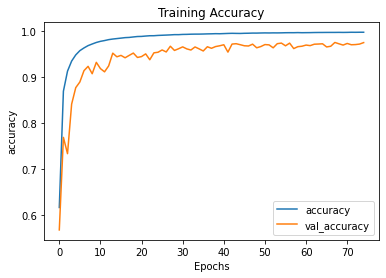

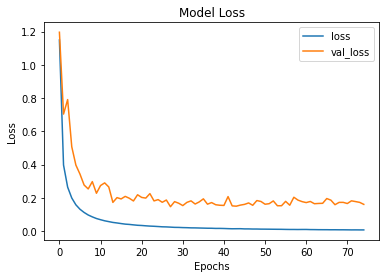

In [31]:
# converting hsitory to dataframe
pd.DataFrame(history.history)

pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [32]:
print(classification_report(yyy_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     22457
           1       0.98      0.99      0.98      1274
           2       0.98      0.99      0.99      1986
           3       0.80      0.91      0.85       618
           4       0.48      0.50      0.49        22
           5       0.38      0.91      0.53        22
           6       0.90      0.92      0.91       982
           7       0.70      0.84      0.77       169
           8       0.44      0.83      0.57        54
           9       0.79      1.00      0.88        26
          10       0.98      0.97      0.98      1932
          11       0.73      0.86      0.79       320
          12       0.00      0.00      0.00         3

    accuracy                           0.97     29865
   macro avg       0.70      0.82      0.75     29865
weighted avg       0.98      0.97      0.98     29865



In [33]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



Confusion matrix, without normalization


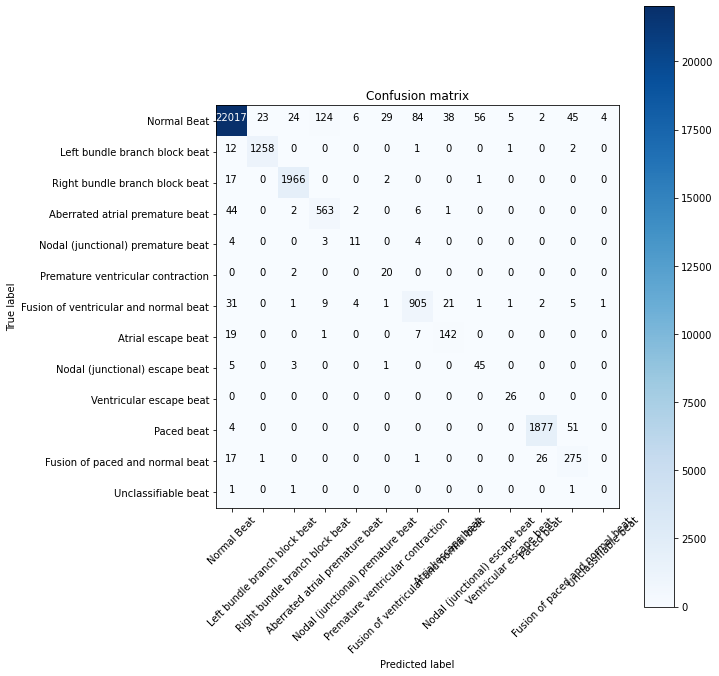

In [34]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(yyy_test, y_pred)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=[
                                           
                'Normal Beat',
                'Left bundle branch block beat',
                'Right bundle branch block beat',
               # 'Atrial premature beat',
                'Aberrated atrial premature beat',
                'Nodal (junctional) premature beat',
                #'Supraventricular premature beat',
                'Premature ventricular contraction',
                'Fusion of ventricular and normal beat',
                'Atrial escape beat',
                'Nodal (junctional) escape beat',
                'Ventricular escape beat',
                'Paced beat',
                'Fusion of paced and normal beat',
                'Unclassifiable beat'

],
                      title='Confusion matrix')
plt.show()

In [35]:
clf.save('CNN.h5')

In [36]:
from sklearn import metrics
import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error 


In [37]:
fpr, tpr, thresholds = metrics.roc_curve(yyy_test, y_pred, pos_label=2)

In [38]:
print(fpr)

[0.00000000e+00 1.79346461e-04 1.37738082e-02 8.21765487e-02
 8.33602353e-02 8.70189031e-02 9.42645002e-02 1.30420747e-01
 1.32250081e-01 1.33075074e-01 1.58183579e-01 1.59367266e-01
 2.05351698e-01 1.00000000e+00]


In [39]:
print(tpr)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 5.03524673e-04 5.03524673e-04 5.03524673e-04
 1.51057402e-03 1.51057402e-03 1.51057402e-03 9.91440081e-01
 9.91440081e-01 1.00000000e+00]


In [40]:
print(thresholds)

[13 12 11 10  9  8  7  6  5  4  3  2  1  0]


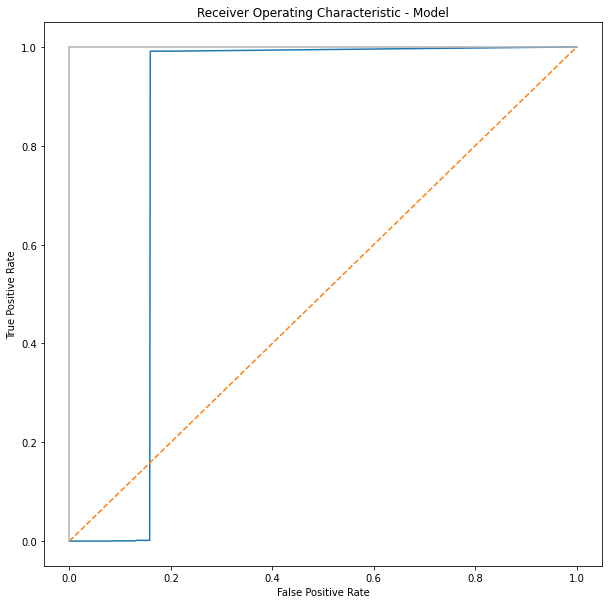

In [41]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Model')
plt.plot(fpr, tpr)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [42]:

auc = metrics.auc(fpr, tpr)
print("Auc is : ")
print(auc )


Auc is : 
0.8374895114829959


In [43]:
import tensorflow.keras.backend as K
import tensorflow as tf
tf.compat.v1.disable_eager_execution()
#tf.compat.v1.reset_default_graph()


run_eagerly = True



def gradcam(model, x, index, layer_name):
    # 取得影像的分類類別
    #with tf.Graph().as_default():
    model = tf.keras.models.load_model('CNN.h5')
    preds = model.predict(x)
    #model._make_predict_function()
    pred_class = np.argmax(preds[index])
    
    # 取得影像分類名稱
    #pred_class_name = imagenet_utils.decode_predictions(preds)[0][0][1]
    
    # 預測分類的輸出向量
    pred_output = model.output[:, pred_class]
    
    # 最後一層 convolution layer 輸出的 feature map
    # ResNet 的最後一層 convolution layer
    last_conv_layer = model.get_layer(layer_name)
    
    # 求得分類的神經元對於最後一層 convolution layer 的梯度
    grads = K.gradients(pred_output, last_conv_layer.output)[0]
    
    # 求得針對每個 feature map 的梯度加總
    #pooled_grads = K.sum(grads, axis=(0, 1, 2))
    pooled_grads = K.sum(grads, axis=(0, 1))
    
    # K.function() 讓我們可以藉由輸入影像至 `model.input` 得到 `pooled_grads` 與
    # `last_conv_layer[0]` 的輸出值，像似在 Tensorflow 中定義計算圖後使用 feed_dict
    # 的方式。
    iterate = K.function([model.input], [pooled_grads, last_conv_layer.output[index]])
    
    # 傳入影像矩陣 x，並得到分類對 feature map 的梯度與最後一層 convolution layer 的 
    # feature map
    pooled_grads_value, conv_layer_output_value = iterate([x])
    
    # 將 feature map 乘以權重，等於該 feature map 中的某些區域對於該分類的重要性
    for i in range(pooled_grads_value.shape[0]):
        conv_layer_output_value[:, i] *= (pooled_grads_value[i])
        
    # 計算 feature map 的 channel-wise 加總
    heatmap = np.sum(conv_layer_output_value, axis=-1)
    
    return heatmap, pred_class

In [44]:
def heatmap_():
    heatmap_2d = np.expand_dims(heatmap,1)
    heatmap_2d = cv2.resize(heatmap_2d, (100,188))

    figure = plt.figure(figsize=(80,4))
    ax = figure.add_subplot(111)
    x = np.arange(0, 188, 1)
    ax.plot(x, data*100)
    ax.imshow(np.transpose(heatmap_2d), cmap="Oranges", extent=[0, 188, -10, 120])
    ax.autoscale(False)
    ax.set_xlim(0, 187)
    ax.set_ylim(-10, 110)
    ax.set_title(title)
    plt.show()

In [45]:
for i, layer in enumerate(clf.layers):
    print(i, layer.name, layer.output_shape)

0 conv1d (None, 186, 32)
1 conv1d_1 (None, 186, 64)
2 conv1d_2 (None, 186, 128)
3 max_pooling1d (None, 93, 128)
4 dropout (None, 93, 128)
5 flatten (None, 11904)
6 dense (None, 512)
7 dense_1 (None, 1024)
8 dense_2 (None, 13)


In [46]:
def heatmap_3x():
    def preprocess_heatmap(heatmap):
        heatmap_2d = np.expand_dims(heatmap,1)
        heatmap_2d = cv2.resize(heatmap_2d, (100,186))
        heatmap_2d = np.transpose(heatmap_2d)
        return heatmap_2d

    fig, ax = plt.subplots(1,len(name_list)+1,figsize=(20,4))
    x = np.arange(0, 186, 1)
    Collect_attention = list()
    for i in range(1,len(name_list)+1):
        ax[i].plot(x, data*100)
        heatmap_2d = preprocess_heatmap(Collect_heatmap[i-1])
        Collect_attention.append(heatmap_2d[0])
        ax[i].imshow(heatmap_2d, cmap="Oranges", extent=[0, 186, -10, 120])
        ax[i].set_xlim(0, 187)
        ax[i].set_ylim(-10, 110)
        ax[i].set_title(name_list[i-1])
    ax[0].plot(x, data, label="ECG")
    for i in range(len(name_list)):
        ax[0].set_title(title)
        ax[0].plot(x, Collect_attention[i]/np.max(Collect_attention[i]), label=name_list[i])
        ax[0].set_ylim(-0.2, 1)
    ax[0].legend()

    plt.show()

In [47]:
X_display = np.array(X_display).astype(float)

In [48]:
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
y_display = y_display.tolist()

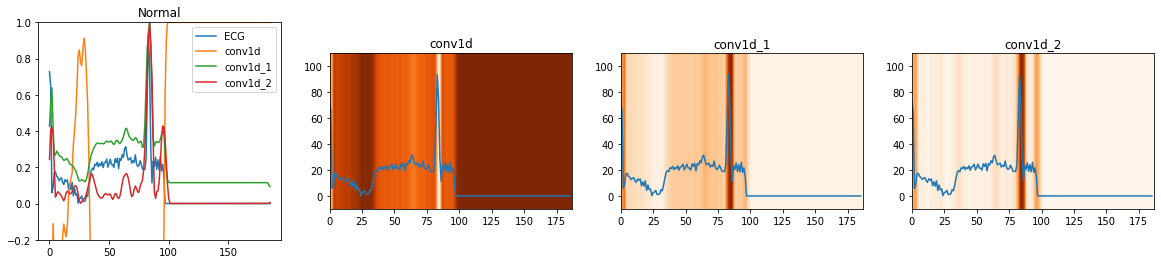

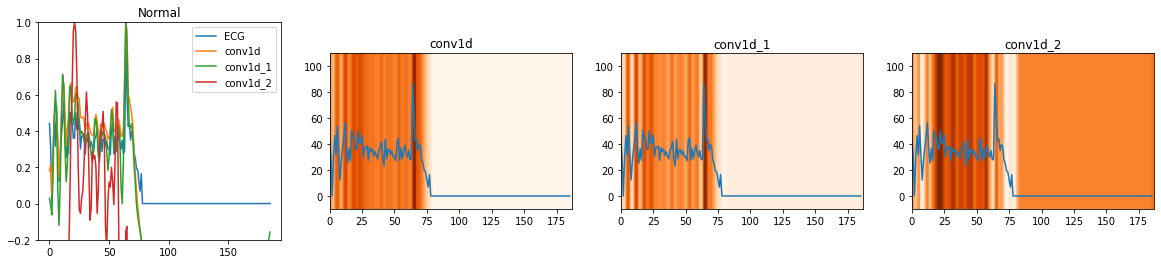

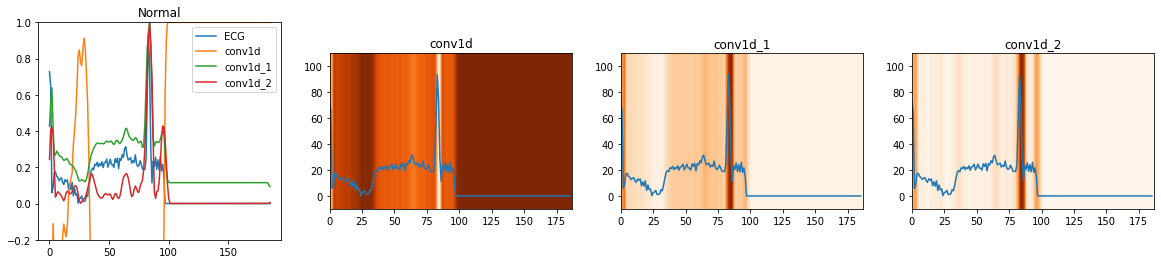

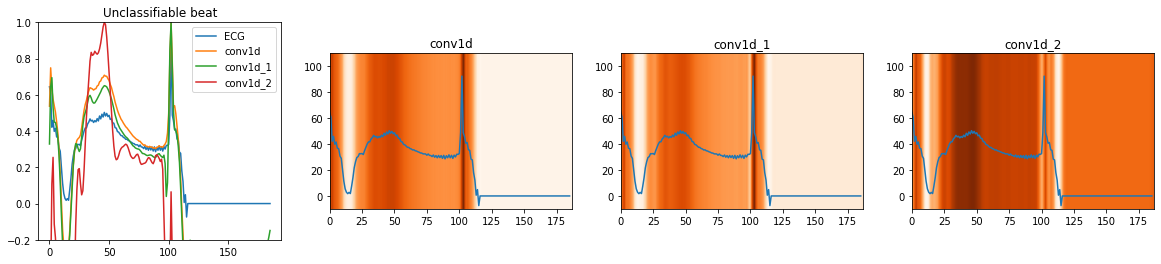

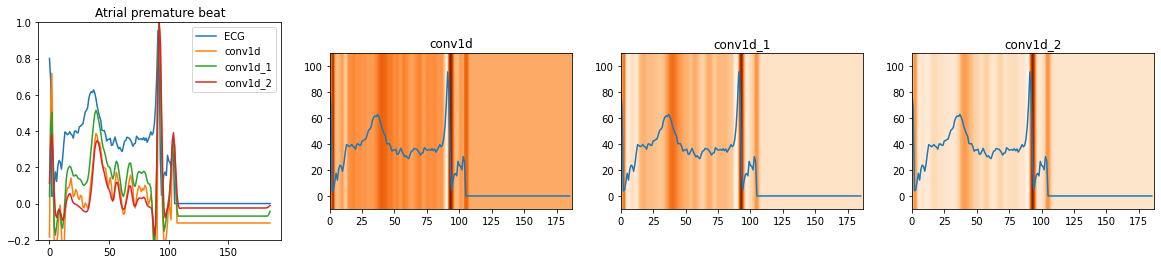

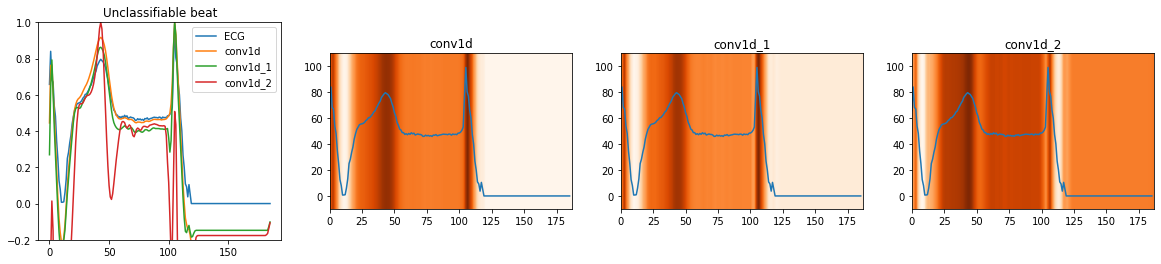

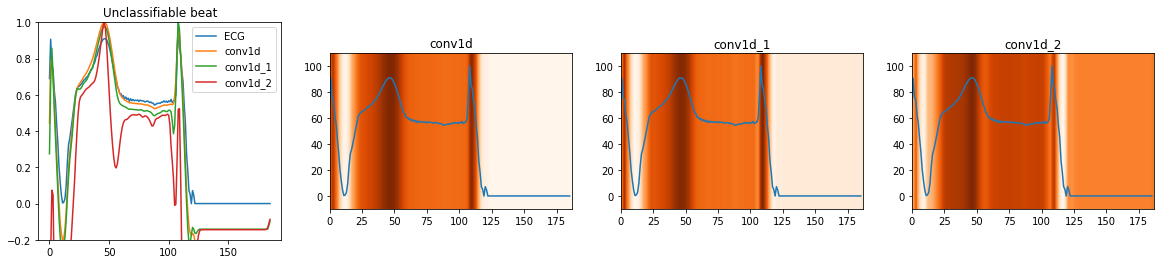

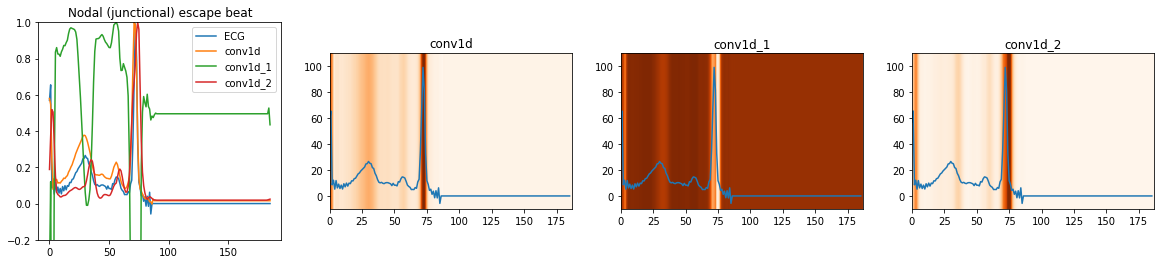

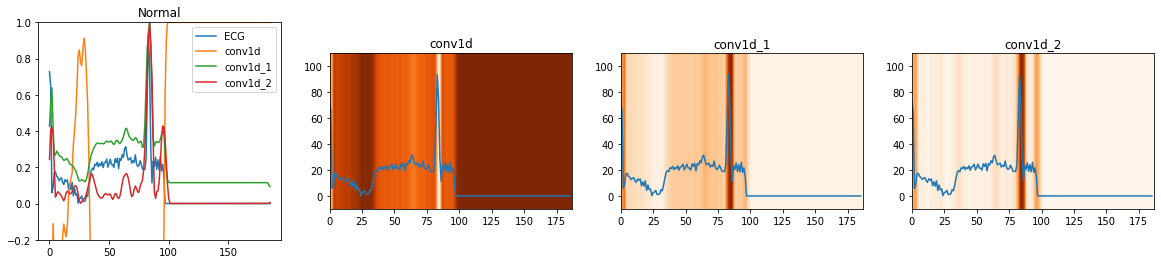

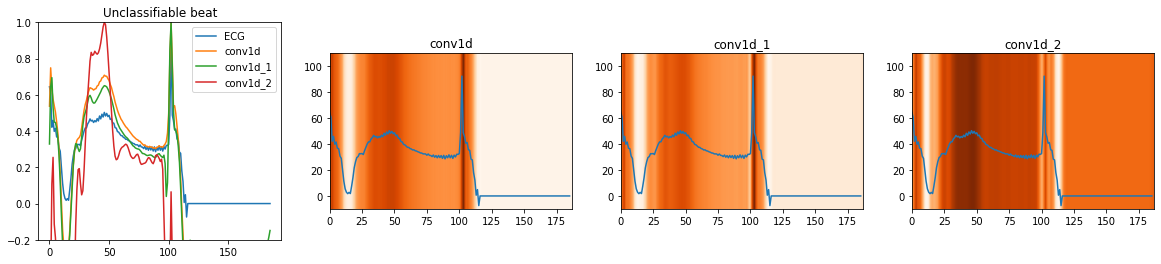

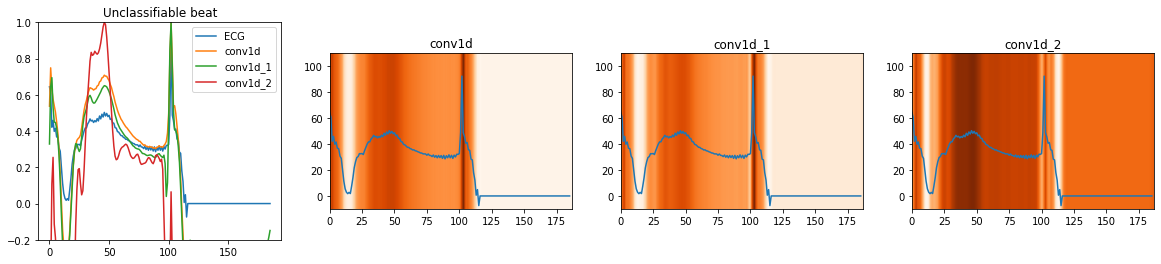

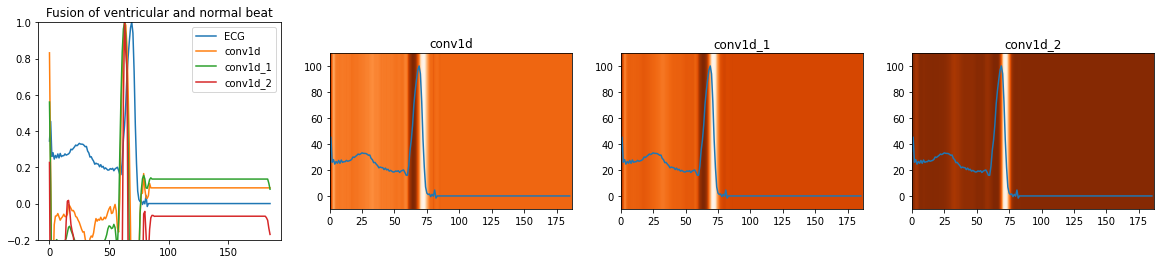

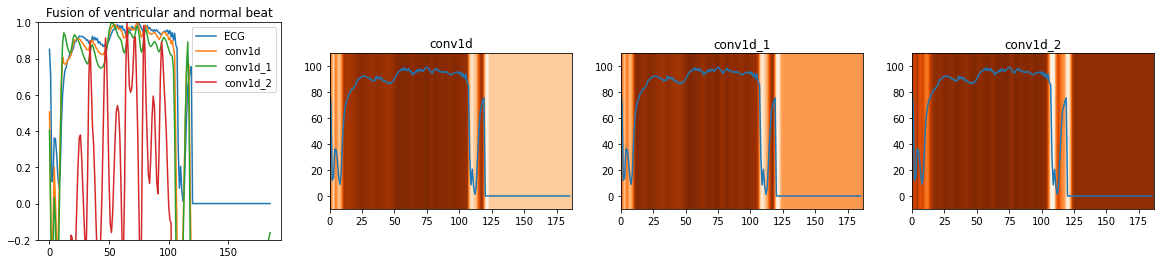

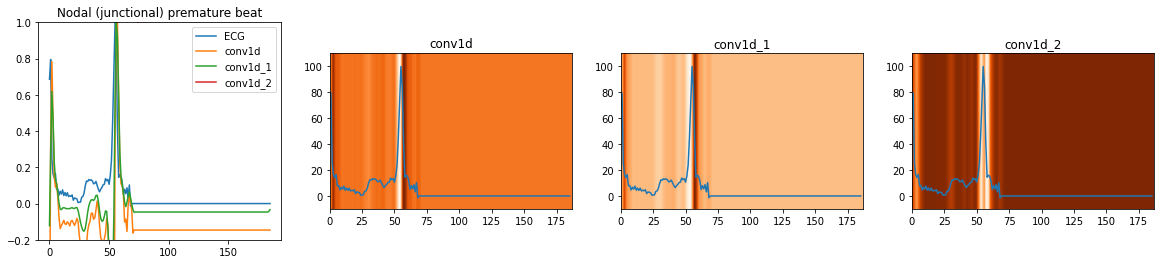

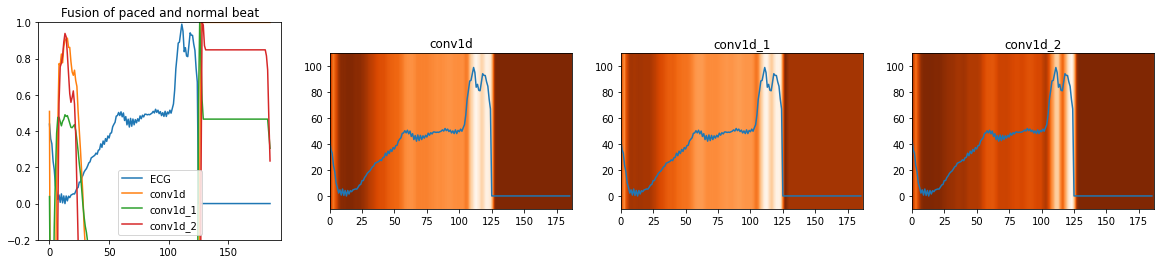

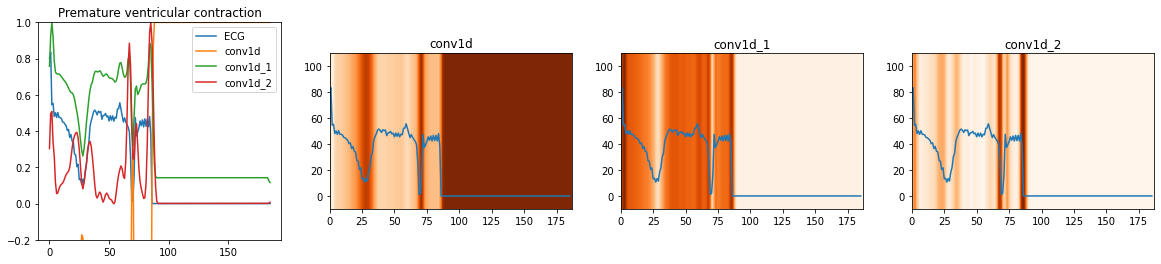

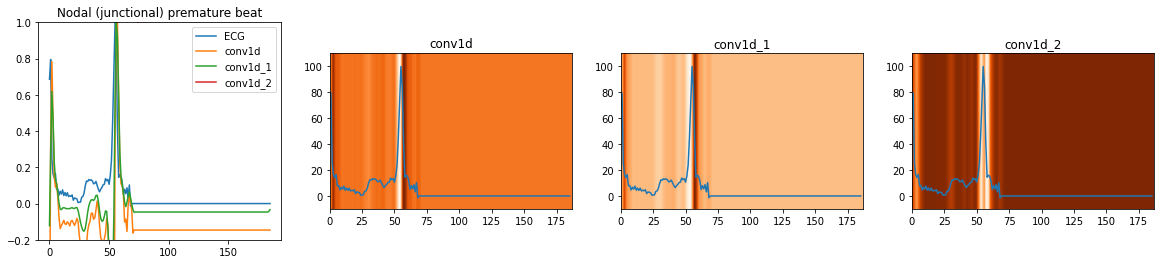

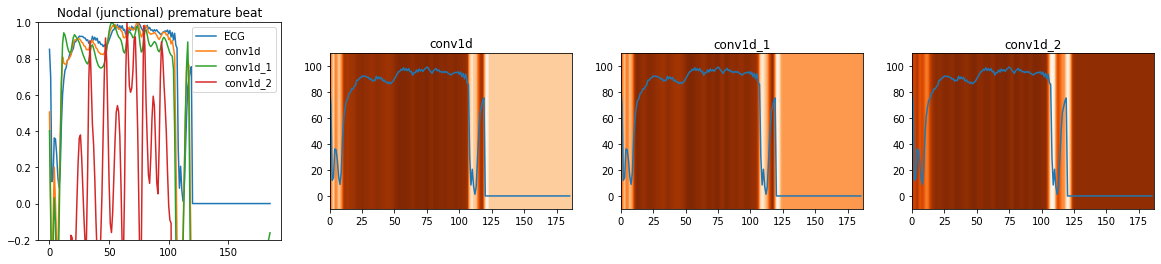

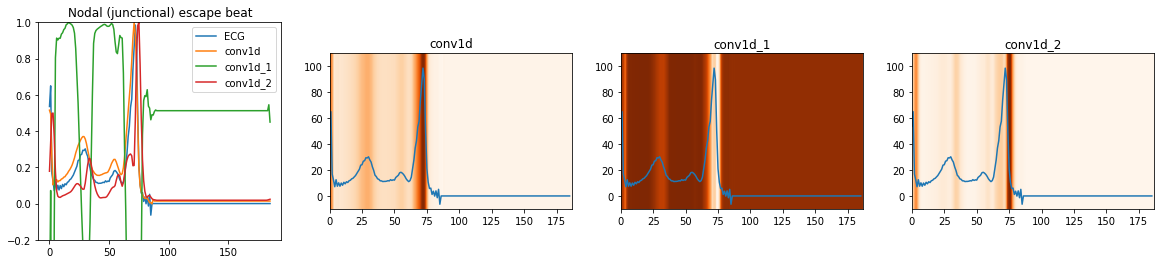

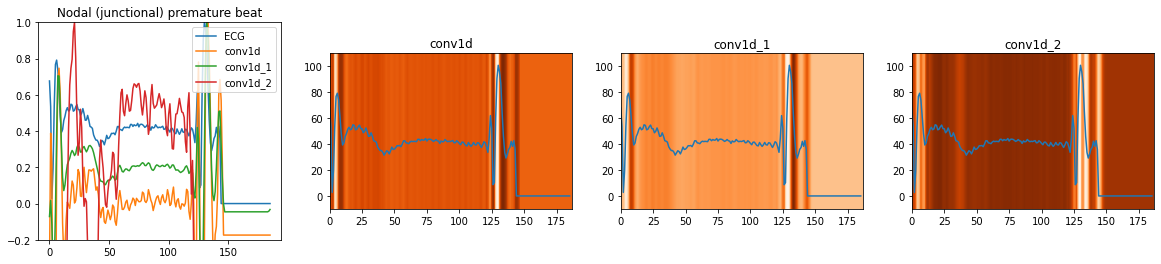

In [51]:
for i in range(20):
    Collect_heatmap = list()
    index = np.random.randint(0,len(X_display))
    name_list = ["conv1d" ,"conv1d_1",  "conv1d_2"]
    for name in name_list:
        heatmap, pred_class = gradcam(clf, X_display, index, name)
        Collect_heatmap.append(heatmap)
    data = X_display[index]
    if int(y_display[index][0]==1): 
      title = "Normal"
    elif int(y_display[index][1]==1):
      title = "Left bundle branch block beat"
    elif int(y_display[index][2]==1):
      title = "Right bundle branch block beat"
    elif int(y_display[index][3]==1):
      title = "Atrial premature beat"
    elif int(y_display[index][4]==1):
      title = "Aberrated atrial premature beat"
    elif int(y_display[index][5]==1):
      title = "Nodal (junctional) premature beat"
   
    elif int(y_display[index][6]==1):
      title = "Premature ventricular contraction"
    elif int(y_display[index][7]==1):
      title = "Fusion of ventricular and normal beat"
 
    elif int(y_display[index][8]==1):
      title = "Nodal (junctional) escape beat"
    elif int(y_display[index][9]==1):
      title = "Ventricular escape beat"
    elif int(y_display[index][10]==1):
      title = "Paced beat"
    elif int(y_display[index][11]==1):
      title = "Fusion of paced and normal beat"
    elif int(y_display[index][12]==1):
      title = "Unclassifiable beat"
   
    heatmap_3x()